In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# import HTML
from IPython.display import HTML

In [9]:
def cost_function(X, centroids, labels):
    cost = 0
    for i in range(len(X)):
        cost += np.linalg.norm(X[i] - centroids[labels[i]]) ** 2
    return cost

Cost Function J: 29655.32


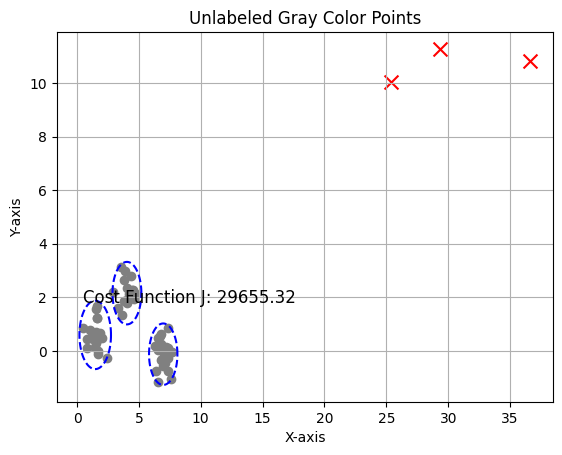

In [10]:

# create unlabeled gray color two cluster zones x2 on y axis and x3 on x-axis

x_cluster_1 = np.random.normal(1.5, 0.5, 20) # Generate 100 points with mean=1.5 and std=0.5 (x values between 0 and 3)
y_cluster_1 = np.random.normal(0.5,0.5, 20) # Generate 100 points with mean=1.0 and std=0.5 (y values between 0 and 2)
x_cluster_2 = np.random.normal(4, 0.5, 20) # Generate 100 points with mean=3.5 and std=0.5 (x values between 3 and 4)
y_cluster_2 = np.random.normal(2, 0.5, 20) # Generate 100 points with mean=1.5 and std=0.5 (y values between 0 and 2)
x_cluster_3 = np.random.normal(7, 0.5, 20) # Generate 100 points with mean=3.5 and std=0.5 (x values between 3 and 4)
y_cluster_3 = np.random.normal(0, 0.5,20) # Generate 100 points with mean=1.5 and std=0.5 (y values between 0 and 2)
X = np.concatenate((x_cluster_1, x_cluster_2, x_cluster_3))
Y = np.concatenate((y_cluster_1, y_cluster_2, y_cluster_3))

# Create 3 circles with center of the means of the 3 clusters and radius of the border of clusters and hoolow middle
theta = np.linspace(0, 2 * np.pi, 100)
for i in range(3):
  mean_x = np.mean(X[i*20:(i+1)*20])
  mean_y = np.mean(Y[i*20:(i+1)*20])
  radius = max(np.sqrt((X[i*20:(i+1)*20] - mean_x) ** 2 + (Y[i*20:(i+1)*20] - mean_y) ** 2))
  circle_x = mean_x + radius * np.cos(theta)
  circle_y = mean_y + radius * np.sin(theta)
  plt.plot(circle_x, circle_y, color='blue', linestyle='--')


# initialize random 3 centroids
centroids = np.random.rand(3, 2) * 7 # Random centroids in the range [0,7] for both x and y
centroids[:, 0] = centroids[:, 0] * 7 # Scale x values to [0,7]
centroids[:, 1] = centroids[:, 1] * 2 # Scale y values to [0,2]

# At the top left corner of the plot, show J (cost function) value
labels = np.zeros(len(X), dtype=int)
for i in range(len(X)):
  distances = np.sqrt(np.sum((centroids - [X[i], Y[i]]) ** 2, axis=1))
  labels[i] = np.argmin(distances)
cost = cost_function(X, centroids, labels)
print(f'Cost Function J: {cost:.2f}')
# fix unsupported format string passed to numpy.ndarray.__format__
plt.text(0.5, 1.8, f'Cost Function J: {cost:.2f}', fontsize=12, color='black')


plt.scatter(X, Y, color='gray')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x', s=100)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Unlabeled Gray Color Points')
plt.grid()
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


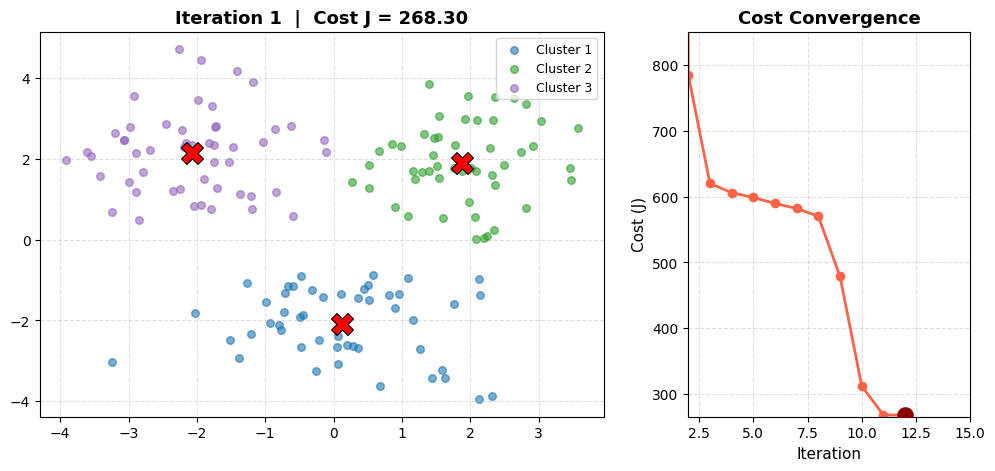

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.gridspec import GridSpec
from IPython.display import HTML

# --- Generate sample data with 3 clear clusters (replace with your X, Y) ---
np.random.seed(42)
X = np.concatenate([np.random.randn(50, 2) + [2, 2],
                    np.random.randn(50, 2) + [-2, 2],
                    np.random.randn(50, 2) + [0, -2]])
Y = X[:, 1]
X = X[:, 0]
# -----------------------------------------------------------------------

data = np.column_stack((X, Y))

# ✅ EXTREME initialization: place centroids WAY outside the data cloud
margin = 10  # increase this for even more dramatic effect

centroids = np.array([
    [x_min - margin, y_min - margin],   # far bottom-left
    [x_max + margin, y_min - margin],   # far bottom-right
    [(x_min + x_max) / 2, y_max + margin],  # far top-center
])

labels = np.zeros(len(data), dtype=int)
cost_history = []

fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 2, width_ratios=[2, 1])
ax_scatter = fig.add_subplot(gs[0])
ax_cost    = fig.add_subplot(gs[1])

colors = ['#1f77b4', '#2ca02c', '#9467bd']

def update(frame):
    global centroids, labels

    # STEP A: Assignment — assign each point to nearest centroid
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    labels[:] = np.argmin(distances, axis=1)

    # STEP B: Update — move centroids to cluster means
    new_centroids = np.array([
        data[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
        for j in range(3)
    ])

    # STEP C: Cost — sum of squared distances to assigned centroid
    cost = np.sum((data - centroids[labels]) ** 2)
    cost_history.append(cost)

    centroids[:] = new_centroids

    # --- Left plot: Scatter + centroids ---
    ax_scatter.clear()
    for j in range(3):
        pts = data[labels == j]
        ax_scatter.scatter(pts[:, 0], pts[:, 1], s=30, alpha=0.6,
                           color=colors[j], label=f'Cluster {j+1}')
        ax_scatter.scatter(*centroids[j], color='red', marker='X',
                           s=250, zorder=5, edgecolors='black', linewidths=0.8)

    ax_scatter.set_title(f'Iteration {frame + 1}  |  Cost J = {cost:.2f}',
                         fontsize=13, fontweight='bold')
    ax_scatter.legend(loc='upper right', fontsize=9)
    ax_scatter.grid(True, linestyle='--', alpha=0.4)

    # --- Right plot: Cost convergence curve ---
    ax_cost.clear()
    ax_cost.plot(range(1, len(cost_history) + 1), cost_history,
                 'o-', color='tomato', linewidth=2, markersize=6)
    ax_cost.scatter([len(cost_history)], [cost_history[-1]],
                    s=120, color='darkred', zorder=5)  # highlight current step
    ax_cost.set_xlim(2, 15)
    ax_cost.set_ylim(266, 850)
    ax_cost.set_xlabel('Iteration', fontsize=11)
    ax_cost.set_ylabel('Cost (J)', fontsize=11)
    ax_cost.set_title('Cost Convergence', fontsize=13, fontweight='bold')
    ax_cost.grid(True, linestyle='--', alpha=0.4)

ani = animation.FuncAnimation(fig, update, frames=10, interval=700, repeat=False)


ani.save('kmeans_cost_function.gif', writer='imagemagick', fps=2)
